In [1]:
import pandas as pd



In [2]:
sentiment=pd.read_csv("./datasets/fear_greed_index.csv")
trades=pd.read_csv("./datasets/historical_data.csv")

In [3]:
sentiment["timestamp"].head(5)


0    1517463000
1    1517549400
2    1517635800
3    1517722200
4    1517808600
Name: timestamp, dtype: int64

In [4]:
trades["Timestamp"].head(5)


0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64

In [5]:

sentiment["timestamp"]=pd.to_datetime(sentiment["timestamp"],unit="s")
trades["Timestamp"]=pd.to_datetime(trades["Timestamp"],unit="ms")

In [6]:
sentiment["timestamp"].head()
trades["Timestamp"].head()

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]

In [7]:
sentiment["date_only"]=sentiment["timestamp"].dt.date
trades["date_only"]=trades["Timestamp"].dt.date


In [8]:
trades["date_only"].duplicated().sum()

np.int64(211217)

In [9]:
merge_df=pd.merge(
    trades,
    sentiment,
    on="date_only",
    how="inner"
)

In [10]:
merge_df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,date_only,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2024-10-27,2024-10-27 05:30:00,74,Greed,2024-10-27


In [11]:

merge_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184263 entries, 0 to 184262
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           184263 non-null  object        
 1   Coin              184263 non-null  object        
 2   Execution Price   184263 non-null  float64       
 3   Size Tokens       184263 non-null  float64       
 4   Size USD          184263 non-null  float64       
 5   Side              184263 non-null  object        
 6   Timestamp IST     184263 non-null  object        
 7   Start Position    184263 non-null  float64       
 8   Direction         184263 non-null  object        
 9   Closed PnL        184263 non-null  float64       
 10  Transaction Hash  184263 non-null  object        
 11  Order ID          184263 non-null  int64         
 12  Crossed           184263 non-null  bool          
 13  Fee               184263 non-null  float64       
 14  Trad

In [12]:
profit_by_sent=merge_df.groupby("classification")["Closed PnL"].mean()

In [13]:
profit_by_sent

classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: Closed PnL, dtype: float64

In [14]:
tradecount_sent=merge_df.groupby("classification").size()

In [15]:
tradecount_sent

classification
Extreme Greed      6962
Fear             133871
Greed             36289
Neutral            7141
dtype: int64

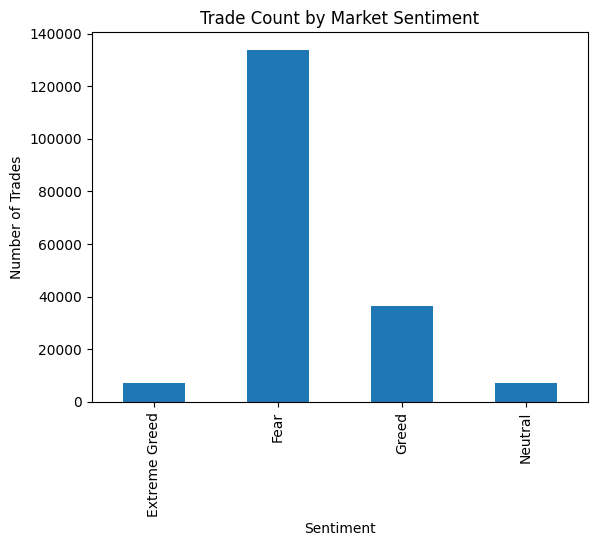

In [16]:
import matplotlib.pyplot as plt
tradecount_sent.plot(
    kind="bar",
    x="classification",
    y="trade_count"
)

plt.title("Trade Count by Market Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")

plt.show()

In [17]:
risk_by_sentiment=merge_df.groupby(
    "classification"
)["Size USD"].mean()

In [18]:
risk_by_sentiment

classification
Extreme Greed    5660.265764
Fear             5259.977837
Greed            3182.883845
Neutral          3058.848110
Name: Size USD, dtype: float64

In [19]:
coin_profit=merge_df.groupby(
    "Coin"
)["Closed PnL"].sum()

In [20]:
coin_profit

Coin
@1        4.967462e+02
@10      -6.348400e-02
@100      2.762714e+01
@103      3.855804e+01
@107      2.776898e+06
              ...     
kBONK     4.156876e+04
kFLOKI    1.560805e+03
kNEIRO    5.319437e+00
kPEPE     2.262998e+04
kSHIB     2.791373e+02
Name: Closed PnL, Length: 239, dtype: float64

In [21]:
test = merge_df.groupby(
    "classification"
).agg({
    "Account": "count",
    "Closed PnL": ["mean","sum"]
})


In [22]:
test

Account Closed PnL              
                 count       mean           sum
classification                                 
Extreme Greed     6962  25.418772  1.769655e+05
Fear            133871  50.047622  6.699925e+06
Greed            36289  87.894859  3.189617e+06
Neutral           7141  22.229713  1.587424e+05

In [27]:
trader_features=merge_df.groupby(
    "Account"
).agg(
        avg_pnl=("Closed PnL","mean"),
        total_pnl=("Closed PnL","sum"),
        avg_size=("Size USD","mean"),
        trade_count=("Account","count")


).reset_index()

In [29]:
trader_features.head(35)

,Account,avg_pnl,total_pnl,avg_size,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,1.600230e+06,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,9.786186,3.770617e+04,1759.743439,3853
2,0x271b280974205ca63b716753467d5a371de622ab,27.716482,3.176309e+04,10908.183944,1146
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.974030,1.323155e+05,509.016502,13266
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.142234,1.686280e+05,3142.909573,3234
5,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,-44.902054,-2.770457e+04,1894.041896,617
6,0x39cef799f8b69da1995852eea189df24eb5cae3c,4.028119,1.445692e+04,4790.575486,3589
7,0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6,161.133275,5.349625e+04,3445.471265,332
8,0x420ab45e0bd8863569a5efbb9c05d91f40624641,520.902331,1.995056e+05,5189.367128,383
9,0x430f09841d65beb3f27765503d0f850b8bce7713,396.329089,4.165419e+05,2580.497012,1051


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
X = trader_features[
    ["avg_pnl", "total_pnl", "avg_size", "trade_count"]
]
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)



In [ ]:
X_scaled

array([[ 2.22847405,  2.80864863,  1.59677736, -0.25973905],
       [-0.71105768, -0.61808014, -0.65134248, -0.25505356],
       [-0.58229804, -0.63111376,  0.7769234 , -0.61744239],
       [-0.70970875, -0.41059499, -0.84660752,  1.00507427],
       [-0.40689374, -0.33095902, -0.43540086, -0.33791972],
       [-1.10378058, -0.76153068, -0.63037564, -0.68826015],
       [-0.75240706, -0.66906745, -0.17816522, -0.29039551],
       [ 0.37578419, -0.58345135, -0.38816456, -0.72641339],
       [ 2.95932957, -0.26324216, -0.11590537, -0.71958597],
       [ 2.06475396,  0.21273429, -0.52320541, -0.63016014],
       [-0.69353638, -0.47715441, -0.84478026,  0.34562567],
       [ 0.3901656 ,  0.77824481,  0.4718929 , -0.21743581],
       [-0.49204546, -0.04002613,  1.74222905,  0.23036273],
       [-0.29840106,  0.18413613,  3.34753788,  0.0323675 ],
       [ 0.16670227, -0.46278327, -0.80432014, -0.6608166 ],
       [ 1.9151663 ,  0.23307137,  0.56661112, -0.61904884],
       [ 1.30046744,  0.

In [33]:
kmeans=KMeans(
    n_clusters=3,
    random_state=42
)
trader_features["cluster"]=kmeans.fit_predict(X_scaled)

In [34]:
print(
    trader_features.groupby("cluster").mean(
        numeric_only=True
    )
)

            avg_pnl      total_pnl      avg_size  trade_count
cluster                                                      
0        112.831331  849271.809134  12629.540973    12300.375
1         49.822131   99776.472422   3463.499265     4096.700
2        395.657239  358886.418574   4877.608161      981.500


In [41]:
account_pnl = merge_df.groupby(
    "Account"
)["Closed PnL"].sum()

best_account = account_pnl.idxmax()
worst_account = account_pnl.idxmin()

print("Best:", best_account)
print("Worst:", worst_account)

Best: 0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23
Worst: 0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891


In [42]:
best_trades = merge_df[
    merge_df["Account"] == best_account
]

worst_trades = merge_df[
    merge_df["Account"] == worst_account
]

In [43]:
print(
    best_trades["classification"].value_counts()
)

classification
Fear             7380
Extreme Greed    3076
Greed            2311
Neutral          1643
Name: count, dtype: int64


In [44]:
print(
    worst_trades["classification"].value_counts()
)

classification
Fear             349
Greed            161
Neutral           80
Extreme Greed     27
Name: count, dtype: int64


In [45]:
print(
    best_trades.groupby(
        "classification"
    )["Closed PnL"].mean()
)

classification
Extreme Greed      0.847495
Fear              75.043089
Greed            615.279684
Neutral           38.092624
Name: Closed PnL, dtype: float64


In [46]:
print(
    best_trades.groupby(
        "classification"
    )["Closed PnL"].mean()
)

classification
Extreme Greed      0.847495
Fear              75.043089
Greed            615.279684
Neutral           38.092624
Name: Closed PnL, dtype: float64


In [47]:
best_loss = best_trades.groupby(
    "classification"
)["Closed PnL"].sum()

print(best_loss)

classification
Extreme Greed    2.606895e+03
Fear             5.538180e+05
Greed            1.421911e+06
Neutral          6.258618e+04
Name: Closed PnL, dtype: float64


In [49]:
print(best_loss.min())

2606.8947559999997
